# Meat Database Exploration

## Table of Contents

1. [Data Loading and Standardization](#data-loading-and-standardization)
2. [Missing Value Handling](#missing-value-handling)
3. [Descriptive Analysis and Visualizations](#descriptive-analysis-and-visualizations)
4. [Ingredient-Level Analysis](#ingredient-level-analysis)
5. [Efficacy Analysis](#efficacy-analysis)
6. [Control vs Non-Control Comparison](#control-vs-non-control-comparison)
7. [Stratified Analysis by Meat Type](#stratified-analysis-by-meat-type)

This notebook starts by loading and cleaning the meat database, then summarizes the main categorical distributions, ingredient prevalence, efficacy relationships, control-vs-ingredient comparisons, and meat-type stratified effects.

## 1. Setup and Data Loading

Import the core libraries needed for the analysis and visualizations.

In [36]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

### Load the Raw CSV File

Read the meat database into a pandas dataframe so the records can be cleaned and reshaped.

In [37]:
path = "data/Modified Database(Information 4).csv"

df = pd.read_csv(path, na_values=["-"])

df.head()

,Article #,ingredient 1,Concentration,Unit of concentration,Normalized concentration % of meat,Chemical composition,source,ingredient 2,Concentration .1,Unit of concentration .1,...,Unnamed: 74,Unnamed: 75,Unnamed: 76,Unnamed: 77,Unnamed: 78,Unnamed: 79,Unnamed: 80,Unnamed: 81,Unnamed: 82,Unnamed: 83
0,ANM-0064,anodic NaCl solution,0.0,% (w/w),0.0,Mineral,other natural sources,cathodic NaCl solution,0.0,% (w/w),...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,ANM-0064,anodic NaCl solution,1.0,% (w/w),1.0,Mineral,other natural sources,cathodic NaCl solution,0.0,% (w/w),...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,ANM-0064,anodic NaCl solution,1.0,% (w/w),1.0,Mineral,other natural sources,cathodic NaCl solution,1.0,% (w/w),...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,ANM-0064,anodic NaCl solution,0.0,% (w/w),0.0,Mineral,other natural sources,cathodic NaCl solution,0.0,% (w/w),...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,ANM-0064,anodic NaCl solution,1.0,% (w/w),1.0,Mineral,other natural sources,cathodic NaCl solution,0.0,% (w/w),...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 2. Cleaning and Standardization

Remove empty rows and unnamed columns, normalize the field names, and reshape the ingredient records into a long format for analysis.

In [38]:
# Removing unnamed columns and empty rows
df = df.loc[:, ~df.columns.astype(str).str.contains("Unnamed")]
df = df.dropna(how="all")

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 531 entries, 0 to 530
Data columns (total 54 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   Article #                              531 non-null    str    
 1   ingredient 1                           531 non-null    str    
 2   Concentration                          452 non-null    float64
 3   Unit of concentration                  446 non-null    str    
 4   Normalized concentration % of meat     531 non-null    float64
 5   Chemical composition                   426 non-null    str    
 6   source                                 438 non-null    str    
 7   ingredient 2                           151 non-null    str    
 8   Concentration .1                       151 non-null    float64
 9   Unit of concentration .1               151 non-null    str    
 10  Normalized concentration %             145 non-null    float64
 11  Chemical chomposi

In [39]:
def normalize_column_names(df):
    df.columns = df.columns.str.strip().str.lower().str.replace(" ", "_")
    return df

df = normalize_column_names(df)

In [40]:
metadata_start = df.columns.get_loc("immersion_time")
metadata_cols = df.columns[metadata_start:]

ingredient_blocks = []

for i in range(1, 5):
    ingredient_blocks.append(
        pd.DataFrame({
            "article_#": df["article_#"],
            "ingredient_id": i,
            "ingredient": df[f"ingredient_{i}"],
            "concentration": df.iloc[:, 1 + (i - 1) * 6 + 1],
            "unit_of_concentration": df.iloc[:, 1 + (i - 1) * 6 + 2],
            "normalized_concentration_%_of_meat": df.iloc[:, 1 + (i - 1) * 6 + 3],
            "chemical_composition": df.iloc[:, 1 + (i - 1) * 6 + 4],
            "source": df.iloc[:, 1 + (i - 1) * 6 + 5],
        }).join(df[metadata_cols])
    )

df_long = (
    pd.concat(ingredient_blocks, ignore_index=True)
      .dropna(subset=["ingredient"])
      .reset_index(drop=True)
)

df = df_long

In [41]:
def normalize_values(df):
    obj_cols = df.select_dtypes(include="object").columns
    df[obj_cols] = df[obj_cols].fillna("").apply(
        lambda s: s.str.strip().str.lower()
    )
    return df

df = normalize_values(df)

C:\Users\safae\AppData\Local\Temp\ipykernel_28252\1788564109.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  obj_cols = df.select_dtypes(include="object").columns


In [42]:
df.loc[pd.to_numeric(df["normalized_concentration_%_of_meat"], errors="coerce").eq(0), "ingredient"] = "control"

## 3. Missing Value Handling

Identify missing chemical composition and source values, then fill them using the curated ingredient mapping.

In [43]:
null_chem_source = df[df["chemical_composition"].isna() | df["source"].isna()]

print("Rows with null chemical_composition or source:", len(null_chem_source))
print("Ingredients affected:", null_chem_source["ingredient"].dropna().unique())

null_chem_source[[
    "article_#",
    "ingredient_id",
    "ingredient",
    "chemical_composition",
    "source"
]].drop_duplicates().sort_values(["ingredient_id", "ingredient"])

Rows with null chemical_composition or source: 0
Ingredients affected: <StringArray>
[]
Length: 0, dtype: str


,article_#,ingredient_id,ingredient,chemical_composition,source


In [44]:
# Fill missing chemical_composition and source values using a curated mapping
# Mapping derived from the domain table provided by the user
mapping = {
    'chlorine dioxide': ('mineral', 'other natural sources'),
    'so2': ('mineral', 'other natural sources'),
    'sodium benzoate': ('organic acid', 'other natural sources'),
    'sodium ascorbate': ('organic acid', 'plant'),
    'sodium chloride': ('mineral', 'other natural sources'),
    'bha/bht': ('organic compound (antioxidant)', 'other natural sources'),
    'activin': ('polyphenol', 'plant'),
    'bha': ('organic compound (antioxidant)', 'other natural sources'),
    'pycnogenol': ('polyphenol', 'plant'),
    'rosemary': ('essential oil / polyphenol', 'plant'),
    'stpp': ('mineral', 'other natural sources'),
    'α-tocopherol': ('vitamin', 'plant'),
    'alpha-tocopherol': ('vitamin', 'plant'),
    'bht': ('organic compound (antioxidant)', 'other natural sources'),
    'sodium erythorbate': ('organic acid', 'microbial'),
    'nitrate': ('mineral', 'other natural sources'),
    'edta / na2edta': ('chelating agent (organic compound)', 'other natural sources'),
    'edta': ('chelating agent (organic compound)', 'other natural sources'),
    'thyme oil': ('essential oil', 'plant'),
    'turmeric oil': ('essential oil', 'plant'),
    'texturized soy protein': ('protein', 'plant'),
    'texturised soy protein': ('protein', 'plant'),
    'texturized soy protein': ('protein', 'plant'),
    'texturized soy protein': ('protein', 'plant'),
    'texturized soy protein': ('protein', 'plant'),
    'texturized soya protein': ('protein', 'plant'),
    'texturized soya protein': ('protein', 'plant'),
    'texturized soy': ('protein', 'plant'),
    'pea fibre': ('fiber', 'plant'),
    'pea fiber': ('fiber', 'plant'),
    'pea fibre': ('fiber', 'plant')
}
# Normalize mapping keys to simple lowered strings (already lower-case here)
def is_missing(col):
    return col.isna() | (col.astype(str).str.strip() == '')
chem = 'chemical_composition'
src = 'source'
# Ensure ingredient column is string and normalized for matching
ingred = df['ingredient'].astype(str).str.strip().str.lower()
# Track how many assignments we make
assigned = { 'chemical_composition': 0, 'source': 0 }
for key, (chem_val, src_val) in mapping.items():
    # use literal substring matching to handle small variations; avoid regex meta-characters
    mask = ingred.str.contains(key, na=False, regex=False)
    if mask.any():
        # assign chemical_composition where missing
        chem_mask = mask & is_missing(df[chem])
        if chem_mask.any():
            df.loc[chem_mask, chem] = chem_val
            assigned['chemical_composition'] += chem_mask.sum()
        # assign source where missing
        src_mask = mask & is_missing(df[src])
        if src_mask.any():
            df.loc[src_mask, src] = src_val
            assigned['source'] += src_mask.sum()

print(f"Assigned {assigned['chemical_composition']} chemical_composition values and {assigned['source']} source values using mapping.")
# Show remaining rows with missing chemical_composition or source (if any)
remaining = df[is_missing(df[chem]) | is_missing(df[src])][[ 'article_#', 'ingredient_id', 'ingredient', chem, src ]]
print('Remaining rows with missing chemical_composition or source:', len(remaining))
if len(remaining) > 0:
    display(remaining.drop_duplicates().sort_values(['ingredient_id', 'ingredient']).head(50))


Assigned 44 chemical_composition values and 44 source values using mapping.
Remaining rows with missing chemical_composition or source: 160


,article_#,ingredient_id,ingredient,chemical_composition,source
60,anm-0109,1,control,,
72,anm-0110-113,1,control,,
102,anm-0130,1,control,,
106,anm-0136-139,1,control,,
159,anm-0143-147,1,control,,
168,anm-0182-183,1,control,,
172,anm-0185-190,1,control,,
180,anm-0193-194,1,control,,
186,anm-0206-208,1,control,,
216,anm0209-213,1,control,,


## 4. Data Quality Visualization

Inspect the remaining missing-value pattern after cleaning and imputation.

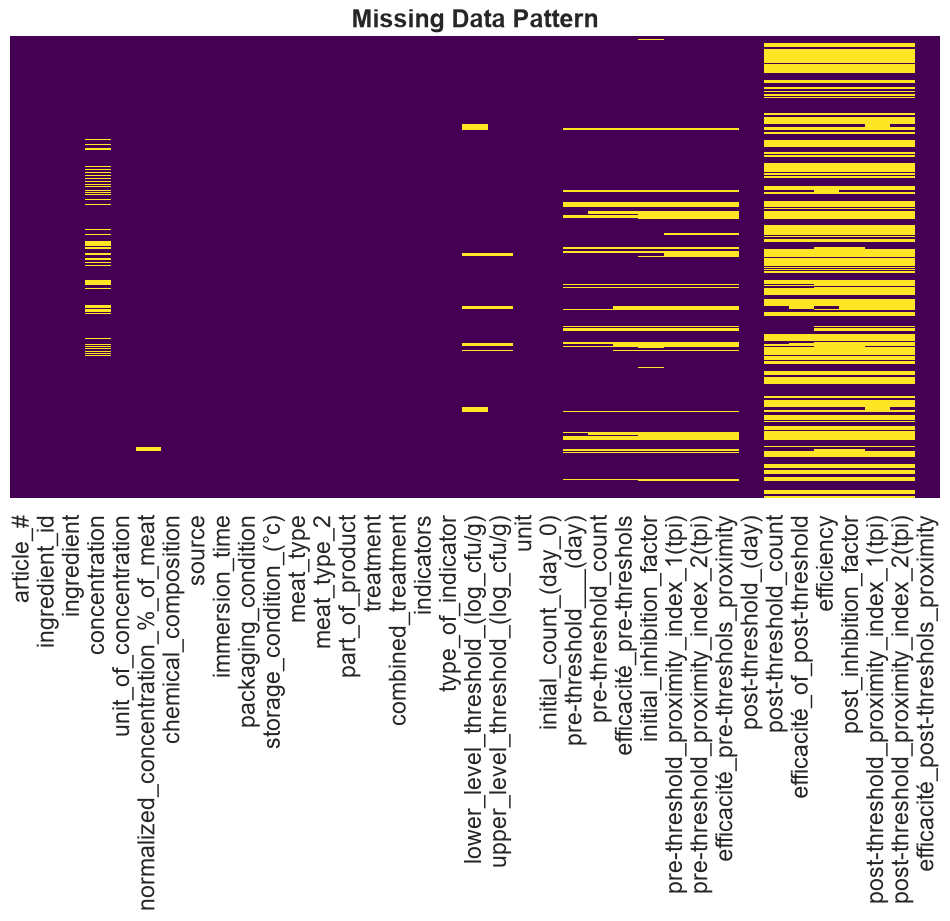

In [45]:
#visualize missing data patterns
plt.figure(figsize=(12, 6))
sns.heatmap(df.isnull(), cbar=False, yticklabels=False, cmap="viridis")
plt.title("Missing Data Pattern")
plt.show()

In [46]:
# Analysis setup
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from IPython.display import display
from scipy import stats
import statsmodels.formula.api as smf

sns.set_theme(style="whitegrid", context="talk")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['axes.titleweight'] = 'bold'

analysis_df = df.copy()
analysis_df = analysis_df.replace(r'^\s*$', np.nan, regex=True)
analysis_df['treatment'] = analysis_df['treatment'].fillna('unspecified')
analysis_df['combined_treatment'] = analysis_df['combined_treatment'].fillna('unspecified')
analysis_df['type_of_indicator'] = analysis_df['type_of_indicator'].fillna('unspecified')
analysis_df['ingredient'] = analysis_df['ingredient'].fillna('unspecified')
analysis_df['meat_type'] = analysis_df['meat_type'].fillna('unspecified')
analysis_df['part_of_product'] = analysis_df['part_of_product'].fillna('unspecified')
analysis_df['chemical_composition'] = analysis_df['chemical_composition'].fillna('unspecified')
analysis_df['source'] = analysis_df['source'].fillna('unspecified')

numeric_cols = [
    'normalized_concentration_%_of_meat',
    'initial_count_(day_0)',
    'lower_level_threshold_(log_cfu/g)',
    'upper_level_threshold_(log_cfu/g)',
    'pre-threshold_count',
    'post-threshold_count',
    'efficacité_pre-threshols',
    'efficacité_of_post-threshold',
    'efficiency',
    'initial_inhibition_factor',
    'pre-threshold_proximity_index_1(tpi)',
    'pre-threshold_proximity_index_2(tpi)',
    'efficacité_pre-threshols_proximity',
    'post_inhibition_factor',
    'post-threshold_proximity_index_1(tpi)',
    'post-threshold_proximity_index_2(tpi)',
    'efficacité_post-threshols_proximity'
]
for col in numeric_cols:
    if col in analysis_df.columns:
        analysis_df[col] = pd.to_numeric(analysis_df[col], errors='coerce')

analysis_df = analysis_df.rename(columns={
    'normalized_concentration_%_of_meat': 'normalized_concentration_pct',
    'efficacité_pre-threshols_proximity': 'pre_threshold_efficacy_proximity',
    'efficacité_post-threshols_proximity': 'post_threshold_efficacy_proximity',
    'efficacité_pre-threshols': 'pre_threshold_efficacy',
    'efficacité_of_post-threshold': 'post_threshold_efficacy'
})

def make_caption(fig, text):
    fig.text(0.5, 0.01, text, ha='center', va='bottom', fontsize=10, color='dimgray')

def add_value_labels(ax, fmt='{:.0f}'):
    for container in ax.containers:
        ax.bar_label(container, labels=[fmt.format(v) for v in container.datavalues], padding=3, fontsize=9)

def ci_mean(series, confidence=0.95):
    values = pd.to_numeric(series, errors='coerce').dropna()
    n = len(values)
    if n == 0:
        return np.nan, np.nan, np.nan
    mean = values.mean()
    if n == 1:
        return mean, mean, mean
    sem = stats.sem(values)
    margin = stats.t.ppf((1 + confidence) / 2.0, n - 1) * sem
    return mean, mean - margin, mean + margin

def cramers_v(table):
    chi2 = stats.chi2_contingency(table, correction=False)[0]
    n = table.to_numpy().sum()
    r, k = table.shape
    return np.sqrt((chi2 / n) / max(1, min(k - 1, r - 1))) if n else np.nan

def kruskal_epsilon_squared(h_stat, n, k):
    return max(0, (h_stat - k + 1) / (n - k)) if n > k else np.nan

def safe_top_counts(series, n=20):
    return series.value_counts(dropna=False).head(n).rename_axis(series.name).reset_index(name='count')


## 5. Descriptive Analysis and Visualizations

Summarize the main categorical distributions with counts and percentages for categories, ingredients, treatment methods, and meat types.

Distribution of items by category (type_of_indicator): metric = count and percentage of rows


,category,count,percentage
0,microbial,442,59.090909
1,chemical,304,40.641711
2,unspecified,2,0.267380


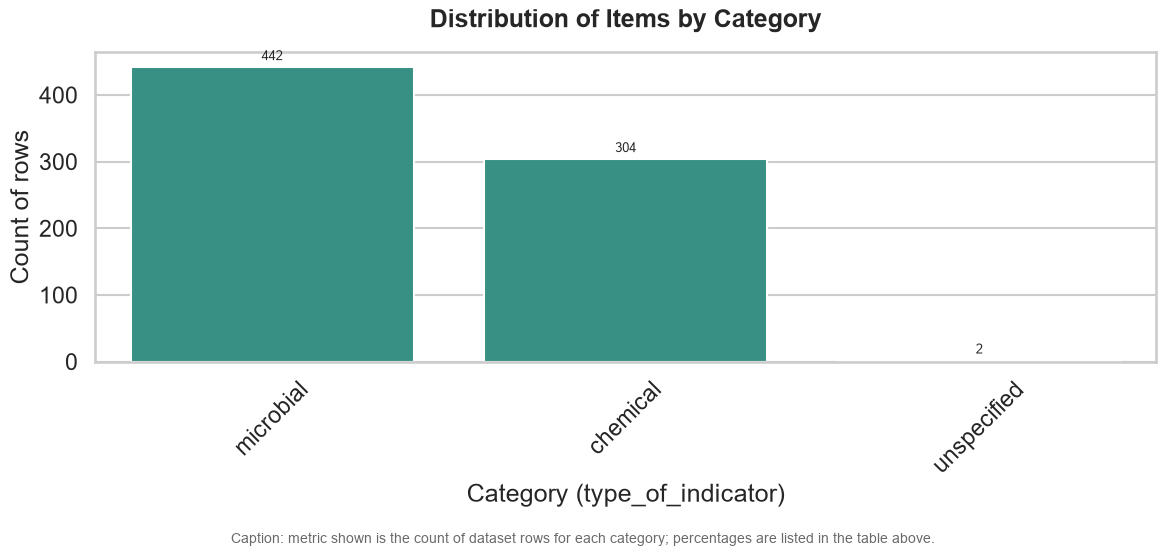

Ingredient frequency across the full dataset: metric = count and percentage of rows


,ingredient,count,percentage
0,control,216,28.877005
1,nisin,42,5.614973
2,edta,32,4.278075
3,chitosan,30,4.010695
4,pomegranate fruit juice,24,3.208556
5,thyme leaves extract,24,3.208556
6,anodic nacl solution,16,2.139037
7,oregano eo,15,2.005348
8,so2,12,1.604278
9,thyme oil,12,1.604278


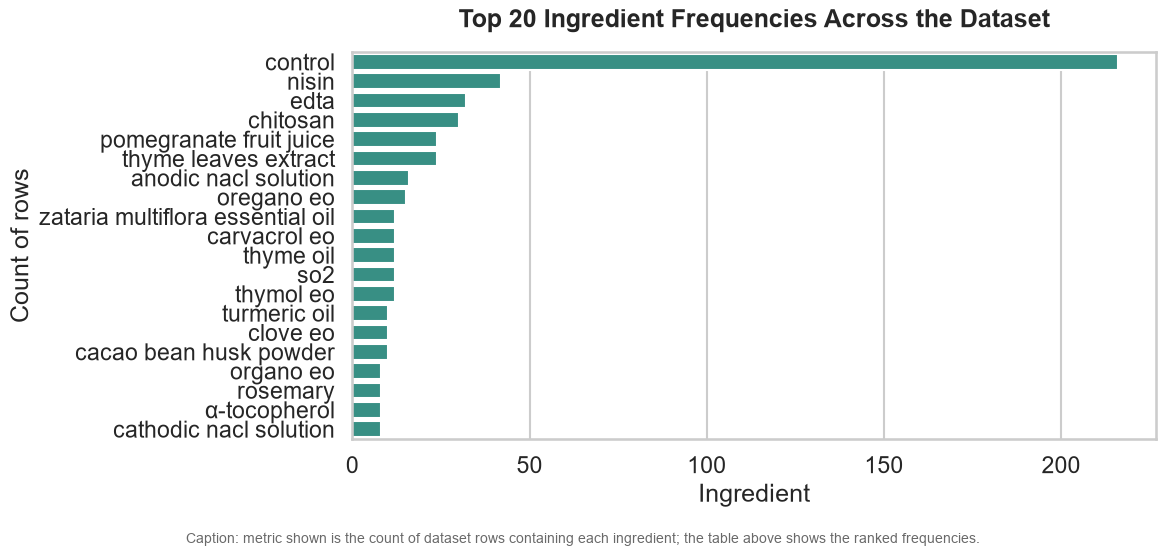

Ingredient frequency grouped by ingredient_id: metric = count and percentage of rows


,ingredient_id,count,percentage
0,1,531,70.989305
1,2,151,20.187166
2,3,42,5.614973
3,4,24,3.208556


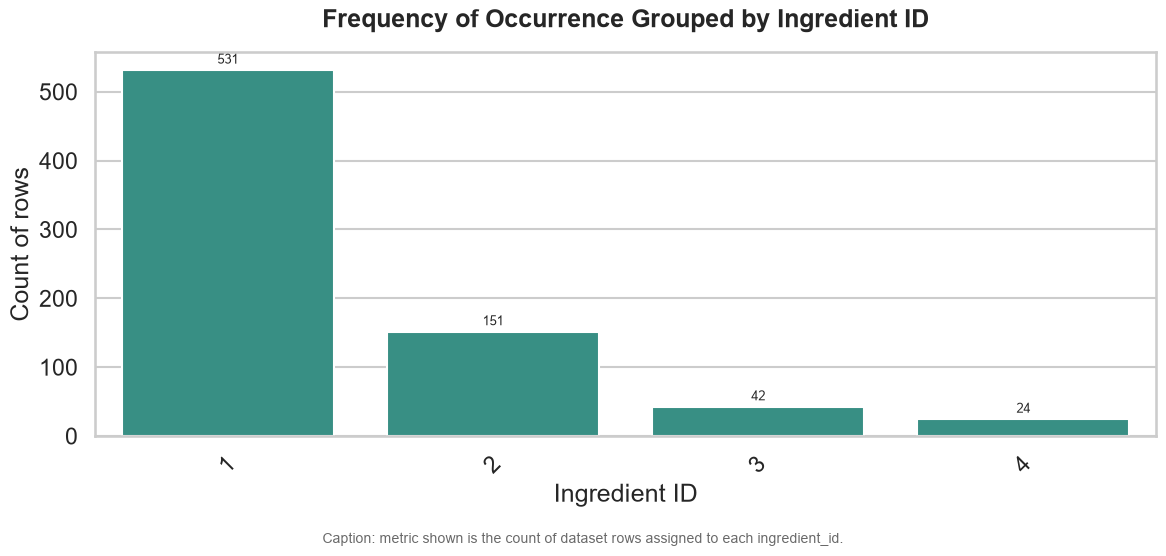

Distribution of treatment methods: metric = count and percentage of rows


,treatment,count,percentage
0,anm,330,44.117647
1,unspecified,257,34.358289
2,map+anm,108,14.438503
3,anm+salt,21,2.807487
4,anm+map,16,2.139037
5,anm+irradiation,12,1.604278
6,anm+heat,4,0.534759


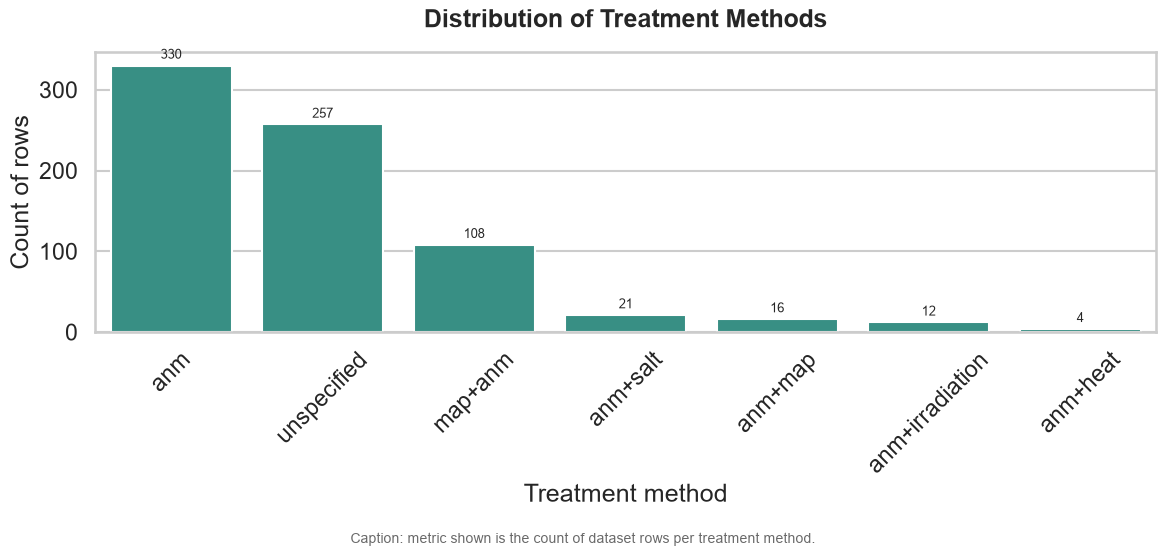

Distribution of meat types: metric = count and percentage of rows


,meat_type,count,percentage
0,chicken,322,43.048128
1,beef,143,19.117647
2,pork,118,15.775401
3,fish,102,13.636364
4,mixed,30,4.010695
5,lamb,16,2.139037
6,lard,6,0.802139
7,goat,6,0.802139
8,horse mackerel,5,0.668449


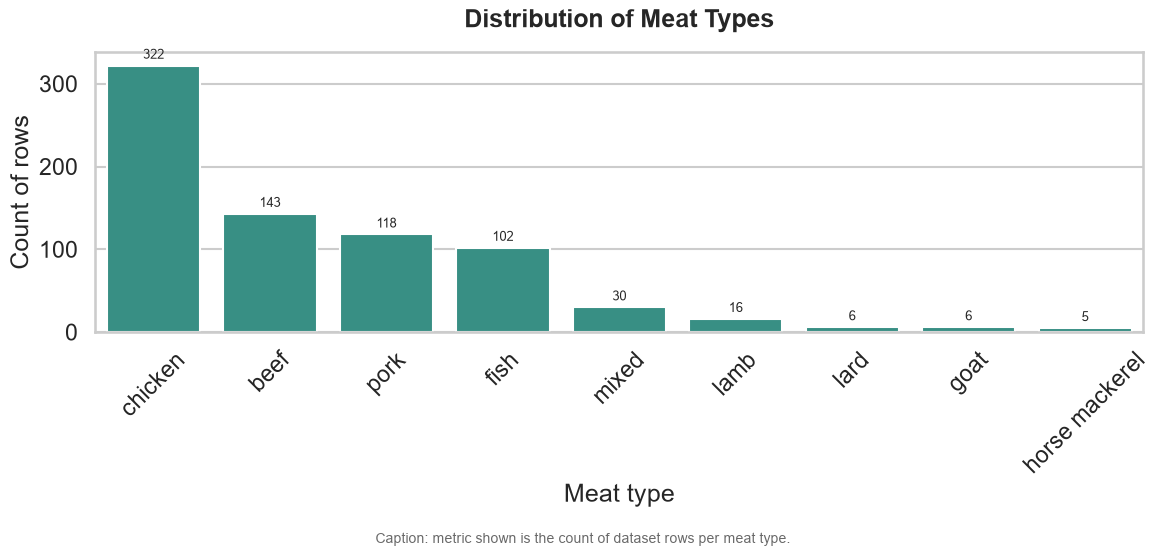

In [ ]:
def plot_count_bar(data, category_col, count_col, title, xlabel, ylabel, subtitle, horizontal=False, color="#2a9d8f"):
    fig, ax = plt.subplots(figsize=(12, 6))
    if horizontal:
        sns.barplot(data=data, y=category_col, x=count_col, ax=ax, color=color)
        ax.invert_yaxis()
    else:
        sns.barplot(data=data, x=category_col, y=count_col, ax=ax, color=color)
        ax.tick_params(axis='x', rotation=45)
        if len(data) <= 10:
            ax.bar_label(ax.containers[0], fmt='%.0f', padding=3, fontsize=9)
    ax.set_title(title, pad=18)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    make_caption(fig, subtitle)
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()


### 5.1 Category Distribution

Show the share of rows belonging to each indicator category using counts and percentages.

In [ ]:
category_summary = (
    analysis_df['type_of_indicator']
    .value_counts(dropna=False)
    .rename_axis('category')
    .reset_index(name='count')
)
category_summary['percentage'] = category_summary['count'] / len(analysis_df) * 100
display(category_summary)


#### Category Bar Chart

Plot the same indicator-category distribution as a bar chart to make the relative concentration easier to compare.

In [ ]:
fig, ax = plt.subplots(figsize=(10, 5))
sns.barplot(data=category_summary.sort_values('count', ascending=False), x='category', y='count', ax=ax, color='#2a9d8f')
ax.set_title('Distribution of Items by Category', pad=18)
ax.set_xlabel('Category (type_of_indicator)')
ax.set_ylabel('Count of rows')
make_caption(fig, 'Caption: metric shown is the count of dataset rows for each category; percentages are shown in the preceding table.')
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()


## 6. Ingredient-Level Analysis

Rank ingredients, quantify immersion time, compare prevalence across meat types and treatment methods, and test association strength with chi-square statistics.

Ranked ingredient table: metric = count and relative frequency across non-control ingredient rows


,ingredient,count,relative_frequency_%
0,nisin,42,7.894737
1,edta,32,6.015038
2,chitosan,30,5.639098
3,pomegranate fruit juice,24,4.511278
4,thyme leaves extract,24,4.511278
5,anodic nacl solution,16,3.007519
6,oregano eo,15,2.819549
7,so2,12,2.255639
8,thyme oil,12,2.255639
9,carvacrol eo,12,2.255639


Ingredient immersion-time summary: metric = mean and median immersion time in minutes by ingredient


,ingredient,count,mean_immersion_time_minutes,median_immersion_time_minutes,relative_frequency_%
48,nisin,42,30.0,30.0,7.894737
22,edta,32,30.0,30.0,6.015038
12,chitosan,30,2.0,2.0,5.639098
58,pomegranate fruit juice,24,2.0,2.0,4.511278
89,thyme leaves extract,24,NaN,NaN,4.511278
2,anodic nacl solution,16,NaN,NaN,3.007519
53,oregano eo,15,2.0,2.0,2.819549
97,zataria multiflora essential oil,12,2.0,2.0,2.255639
10,carvacrol eo,12,NaN,NaN,2.255639
76,so2,12,NaN,NaN,2.255639


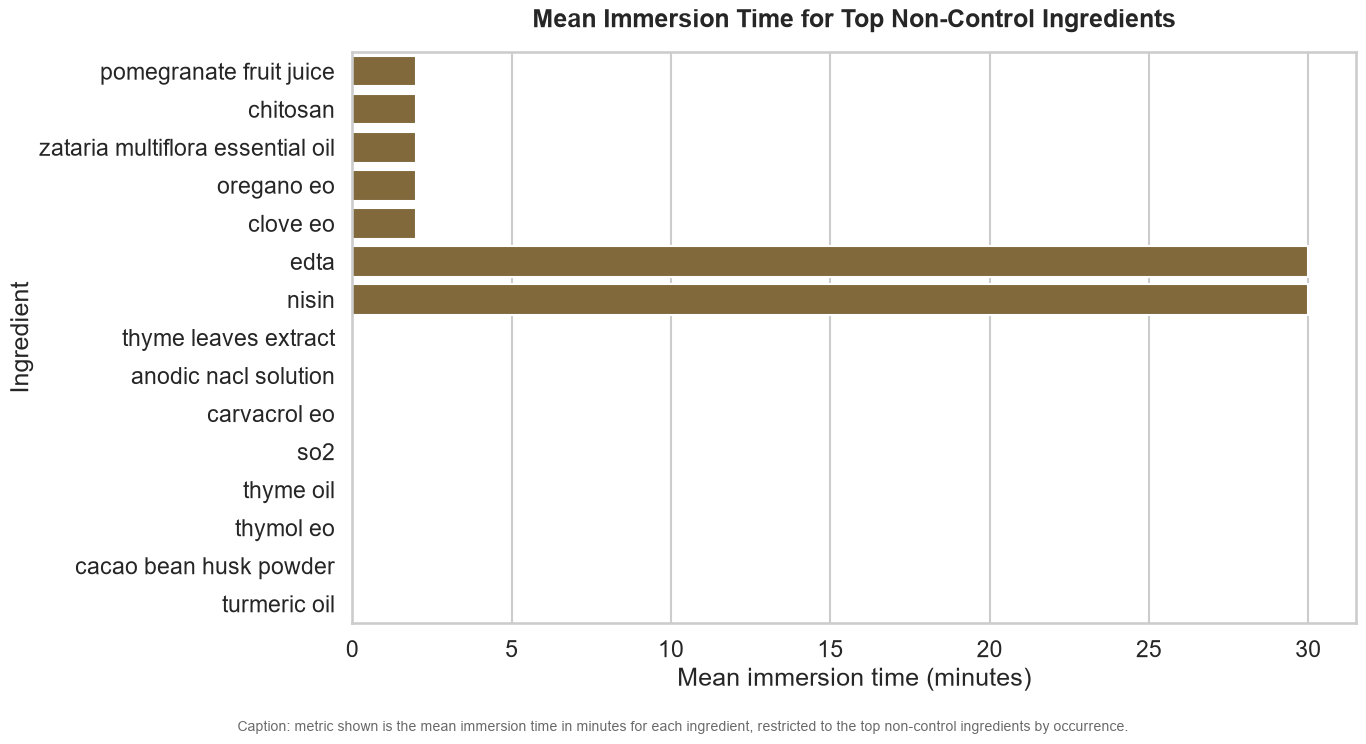

Ingredient by ingredient_id table: metric = count, within-id relative frequency, and immersion time in minutes


,ingredient_id,ingredient,count,relative_frequency_within_ingredient_id_%,mean_immersion_time_minutes,median_immersion_time_minutes
0,1,nisin,42,10.824742,30.0,30.0
1,1,pomegranate fruit juice,24,6.185567,2.0,2.0
2,1,thyme leaves extract,24,6.185567,NaN,NaN
3,1,anodic nacl solution,16,4.123711,NaN,NaN
4,1,oregano eo,15,3.865979,2.0,2.0
5,1,chitosan,12,3.092784,NaN,NaN
6,1,so2,12,3.092784,NaN,NaN
7,1,cacao bean husk powder,10,2.577320,NaN,NaN
8,1,clove eo,10,2.577320,2.0,2.0
9,1,organo eo,8,2.061856,NaN,NaN


Most common ingredients overall: metric = count of rows, excluding control


,ingredient,count,relative_frequency_%
0,nisin,42,7.894737
1,edta,32,6.015038
2,chitosan,30,5.639098
3,pomegranate fruit juice,24,4.511278
4,thyme leaves extract,24,4.511278
5,anodic nacl solution,16,3.007519
6,oregano eo,15,2.819549
7,so2,12,2.255639
8,thyme oil,12,2.255639
9,carvacrol eo,12,2.255639


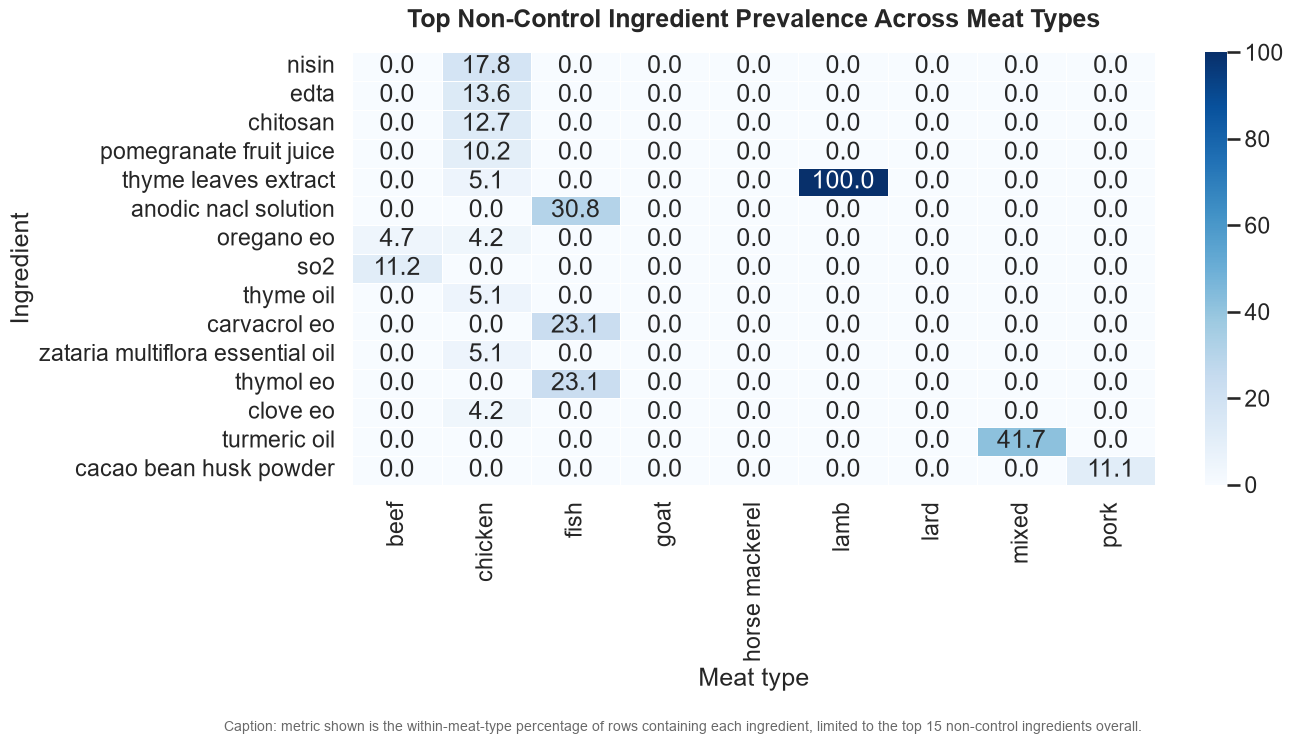

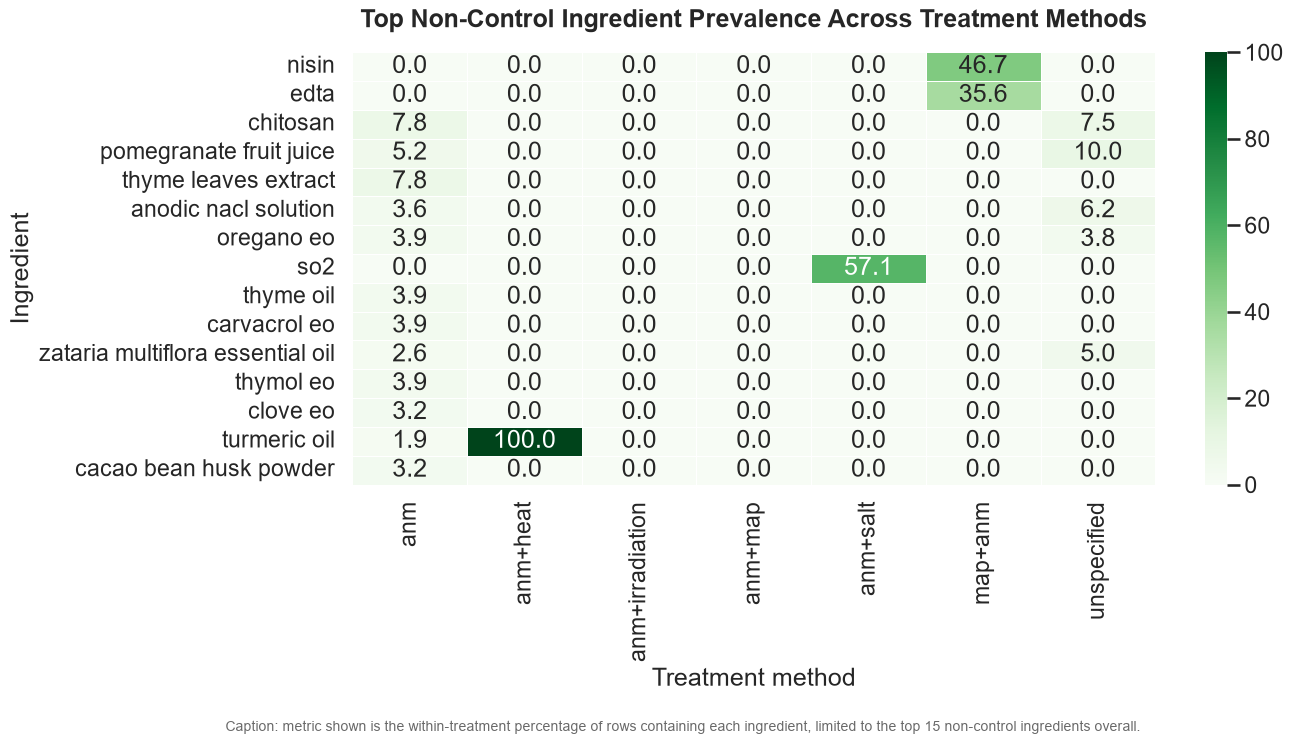

Chi-square tests: metric = association between non-control ingredient prevalence and the grouping variable


,comparison,chi2,dof,p_value,cramers_v,indicator
0,Top non-control ingredients vs meat_type,1255.850798,120,1.874086e-188,0.543211,ingredient prevalence
1,Top non-control ingredients vs treatment,1004.998445,90,1.707752e-154,0.561114,ingredient prevalence


In [ ]:
# Ingredient occurrence counts and relative frequencies
ingredient_base = analysis_df[analysis_df['ingredient'] != 'control'].copy()

def parse_immersion_time_minutes(value):
    if pd.isna(value):
        return np.nan
    text = str(value).strip().lower()
    extracted = pd.Series([text]).str.extract(r'(\d+(?:\.\d+)?)', expand=False).iloc[0]
    if pd.isna(extracted):
        return np.nan
    amount = float(extracted)
    if 'day' in text:
        return amount * 24 * 60
    if 'hour' in text or ' hr' in text or text.endswith('h'):
        return amount * 60
    return amount

ingredient_base['immersion_time_minutes'] = ingredient_base['immersion_time'].apply(parse_immersion_time_minutes)
ingredient_rank = (
    ingredient_base['ingredient']
    .value_counts(dropna=False)
    .rename_axis('ingredient')
    .reset_index(name='count')
)
ingredient_rank['relative_frequency_%'] = ingredient_rank['count'] / len(ingredient_base) * 100
display(ingredient_rank.head(25))


#### Ingredient Immersion Time Summary

Summarize the observed immersion time in minutes for each ingredient and keep the control sample excluded from the ingredient ranking.

In [ ]:
ingredient_immersion = (
    ingredient_base.groupby('ingredient')
    .agg(
        count=('ingredient', 'size'),
        mean_immersion_time_minutes=('immersion_time_minutes', 'mean'),
        median_immersion_time_minutes=('immersion_time_minutes', 'median'),
    )
    .reset_index()
    .merge(ingredient_rank[['ingredient', 'relative_frequency_%']], on='ingredient', how='left')
    .sort_values(['count', 'mean_immersion_time_minutes'], ascending=[False, False])
)
display(ingredient_immersion.head(25))


#### Top Ingredient Immersion Plot

Visualize the mean immersion time for the most frequent non-control ingredients.

In [ ]:
fig, ax = plt.subplots(figsize=(14, 8))
top_immersion = ingredient_immersion.head(15).sort_values('mean_immersion_time_minutes', ascending=True)
sns.barplot(data=top_immersion, y='ingredient', x='mean_immersion_time_minutes', ax=ax, color='#8c6d31')
ax.set_title('Mean Immersion Time for Top Non-Control Ingredients', pad=18)
ax.set_xlabel('Mean immersion time (minutes)')
ax.set_ylabel('Ingredient')
make_caption(fig, 'Caption: metric shown is the mean immersion time in minutes for each ingredient, restricted to the top non-control ingredients by occurrence.')
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()


#### Ingredient Occurrence by Ingredient ID

Show how often each ingredient appears within each ingredient slot and how long those records were immersed.

In [ ]:
ingredient_by_id = (
    ingredient_base.groupby(['ingredient_id', 'ingredient'])
    .size()
    .reset_index(name='count')
    .sort_values(['ingredient_id', 'count', 'ingredient'], ascending=[True, False, True])
)
ingredient_by_id['relative_frequency_within_ingredient_id_%'] = (
    ingredient_by_id['count']
    / ingredient_by_id.groupby('ingredient_id')['count'].transform('sum')
    * 100
)
ingredient_by_id = ingredient_by_id.merge(
    ingredient_base.groupby(['ingredient_id', 'ingredient'])['immersion_time_minutes']
    .agg(mean_immersion_time_minutes='mean', median_immersion_time_minutes='median')
    .reset_index(),
    on=['ingredient_id', 'ingredient'],
    how='left'
)
display(ingredient_by_id.head(40))


#### Ingredient Prevalence Heatmaps

Compare the most common non-control ingredients across meat types and treatment methods.

In [ ]:
top_ingredients = ingredient_rank.head(15)['ingredient'].tolist()
meat_pivot = pd.crosstab(ingredient_base['ingredient'], ingredient_base['meat_type'])
treatment_pivot = pd.crosstab(ingredient_base['ingredient'], ingredient_base['treatment'])
meat_top_pct = meat_pivot.loc[top_ingredients].div(meat_pivot.sum(axis=0), axis=1) * 100
treatment_top_pct = treatment_pivot.loc[top_ingredients].div(treatment_pivot.sum(axis=0), axis=1) * 100
fig, axes = plt.subplots(1, 2, figsize=(18, 8))
sns.heatmap(meat_top_pct, cmap='Blues', linewidths=0.5, annot=True, fmt='.1f', ax=axes[0])
axes[0].set_title('Top Non-Control Ingredient Prevalence Across Meat Types', pad=14)
axes[0].set_xlabel('Meat type')
axes[0].set_ylabel('Ingredient')
sns.heatmap(treatment_top_pct, cmap='Greens', linewidths=0.5, annot=True, fmt='.1f', ax=axes[1])
axes[1].set_title('Top Non-Control Ingredient Prevalence Across Treatment Methods', pad=14)
axes[1].set_xlabel('Treatment method')
axes[1].set_ylabel('Ingredient')
make_caption(fig, 'Caption: metric shown is within-group percentage of rows containing each ingredient, limited to the top 15 non-control ingredients overall.')
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()


#### Ingredient Association Tests

Test whether the most common non-control ingredients are associated with meat type or treatment method.

In [ ]:
ingredient_base['ingredient_top_group'] = ingredient_base['ingredient'].where(ingredient_base['ingredient'].isin(top_ingredients), 'other')
contingency_meat = pd.crosstab(ingredient_base['ingredient_top_group'], ingredient_base['meat_type'])
contingency_treatment = pd.crosstab(ingredient_base['ingredient_top_group'], ingredient_base['treatment'])
chi2_meat, p_meat, dof_meat, expected_meat = stats.chi2_contingency(contingency_meat)
chi2_treatment, p_treatment, dof_treatment, expected_treatment = stats.chi2_contingency(contingency_treatment)
chi_square_results = pd.DataFrame([
    {
        'comparison': 'Top non-control ingredients vs meat_type',
        'chi2': chi2_meat,
        'dof': dof_meat,
        'p_value': p_meat,
        'cramers_v': cramers_v(contingency_meat),
        'indicator': 'ingredient prevalence'
    },
    {
        'comparison': 'Top non-control ingredients vs treatment',
        'chi2': chi2_treatment,
        'dof': dof_treatment,
        'p_value': p_treatment,
        'cramers_v': cramers_v(contingency_treatment),
        'indicator': 'ingredient prevalence'
    }
])
display(chi_square_results)


## 7. Efficacy Analysis

Analyze concentration–efficacy relationships, categorical effects, confidence intervals, and regression-adjusted interactions with meat type.

Correlation analysis: metric = relationship between normalized concentration and efficacy proximity


,metric,test,coefficient,ci_low,ci_high,p_value,effect_size,practical_significance,indicator
2,post_threshold_efficacy_proximity,pearson,-0.070319,-0.165405,0.024940,0.205395,0.070319,negligible,normalized concentration vs efficacy proximity
3,post_threshold_efficacy_proximity,spearman,-0.097958,-0.193844,0.005712,0.077373,0.097958,negligible,normalized concentration vs efficacy proximity
0,pre_threshold_efficacy_proximity,pearson,-0.074409,-0.133522,-0.004469,0.057187,0.074409,negligible,normalized concentration vs efficacy proximity
1,pre_threshold_efficacy_proximity,spearman,-0.081199,-0.154370,-0.004199,0.037894,0.081199,negligible,normalized concentration vs efficacy proximity


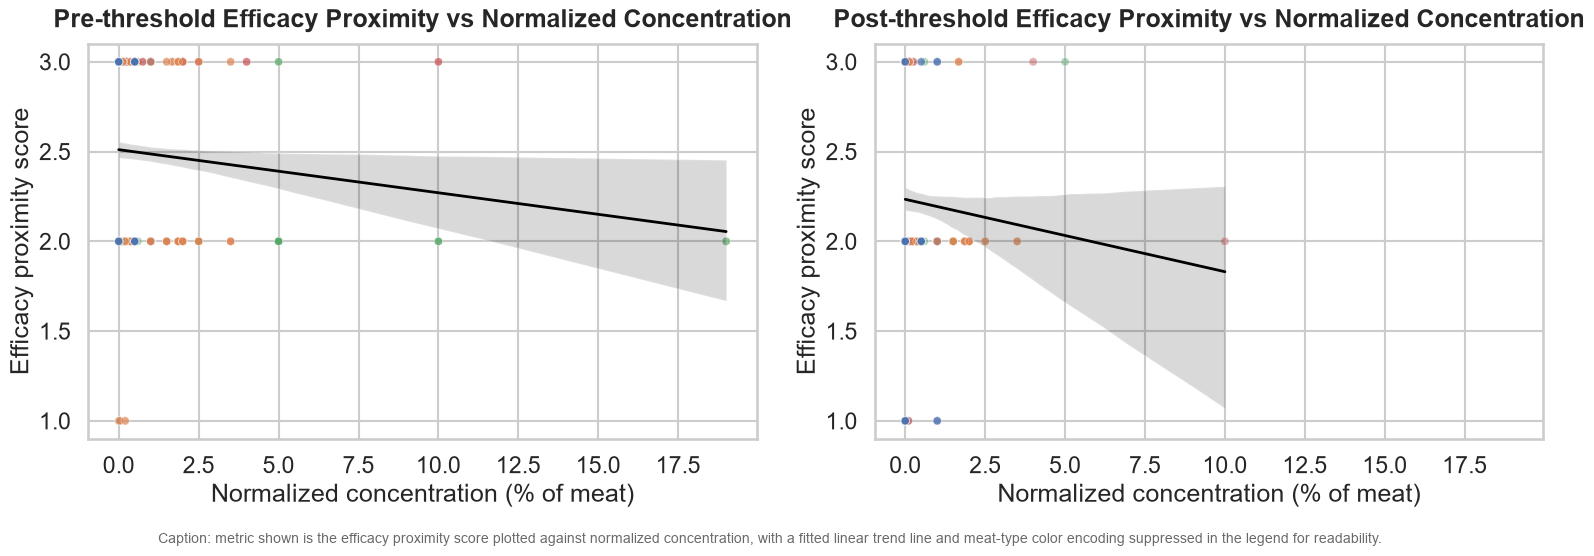

Kruskal-Wallis tests: metric = efficacy proximity differences across categorical groups


,metric,categorical_variable,h_statistic,p_value,epsilon_squared,effect_size,practical_significance,indicator,levels_used,rows_used
9,post_threshold_efficacy_proximity,meat_type,37.285823,1.572868e-07,0.102104,0.102104,moderate,efficacy proximity,5,331
11,post_threshold_efficacy_proximity,ingredient_top_group,42.346576,2.911619e-05,0.095429,0.095429,moderate,efficacy proximity,13,331
8,post_threshold_efficacy_proximity,treatment,23.253095,3.576297e-05,0.062126,0.062126,moderate,efficacy proximity,4,330
7,post_threshold_efficacy_proximity,source,27.897796,9.821956e-05,0.067586,0.067586,moderate,efficacy proximity,7,331
6,post_threshold_efficacy_proximity,chemical_composition,27.750548,2.439915e-04,0.065459,0.065459,moderate,efficacy proximity,8,325
10,post_threshold_efficacy_proximity,type_of_indicator,0.082747,7.736082e-01,0.000000,0.000000,negligible,efficacy proximity,2,330
4,pre_threshold_efficacy_proximity,type_of_indicator,179.489495,6.264481e-41,0.272920,0.272920,large,efficacy proximity,2,656
3,pre_threshold_efficacy_proximity,meat_type,111.837555,3.815917e-21,0.161786,0.161786,large,efficacy proximity,8,656
5,pre_threshold_efficacy_proximity,ingredient_top_group,78.949109,1.086590e-10,0.099609,0.099609,moderate,efficacy proximity,16,658
0,pre_threshold_efficacy_proximity,chemical_composition,49.844743,1.487629e-06,0.059040,0.059040,small,efficacy proximity,13,654


Pre-threshold efficacy proximity: metric = mean efficacy proximity with 95% CI by treatment


,treatment,n,mean,ci_low,ci_high,indicator
1,anm+heat,2,3.000000,3.000000,3.000000,Pre-threshold efficacy proximity
2,anm+irradiation,6,3.000000,3.000000,3.000000,Pre-threshold efficacy proximity
6,unspecified,213,2.549296,2.479426,2.619166,Pre-threshold efficacy proximity
0,anm,304,2.506579,2.447159,2.565999,Pre-threshold efficacy proximity
3,anm+map,8,2.375000,1.942318,2.807682,Pre-threshold efficacy proximity
4,anm+salt,21,2.333333,2.113453,2.553213,Pre-threshold efficacy proximity
5,map+anm,104,2.326923,2.235255,2.418591,Pre-threshold efficacy proximity


Post-threshold efficacy proximity: metric = mean efficacy proximity with 95% CI by treatment


,treatment,n,mean,ci_low,ci_high,indicator
1,anm+irradiation,6,3.000000,3.000000,3.000000,Post-threshold efficacy proximity
4,unspecified,128,2.257812,2.159052,2.356573,Post-threshold efficacy proximity
0,anm,133,2.210526,2.120821,2.300232,Post-threshold efficacy proximity
3,map+anm,63,2.063492,2.001587,2.125397,Post-threshold efficacy proximity
2,anm+map,1,2.000000,2.000000,2.000000,Post-threshold efficacy proximity


Regression model results: metric = adjusted association between efficacy proximity, concentration, meat type, treatment, and ingredient properties


,metric,term,coef,std_err,ci_low,ci_high,p_value,practical_significance
64,post_threshold_efficacy_proximity,C(meat_type)[T.pork],0.528589,0.138328,0.257472,0.799707,1.327618e-04,large
99,post_threshold_efficacy_proximity,normalized_concentration_pct,0.221977,0.098074,0.029755,0.414199,2.361363e-02,small
101,post_threshold_efficacy_proximity,normalized_concentration_pct:C(meat_type)[T.fish],-0.509857,0.359193,-1.213862,0.194147,1.557668e-01,large
61,post_threshold_efficacy_proximity,C(meat_type)[T.chicken],0.124463,0.111000,-0.093093,0.342020,2.621656e-01,small
100,post_threshold_efficacy_proximity,normalized_concentration_pct:C(meat_type)[T.ch...,-0.090602,0.099825,-0.286255,0.105051,3.640854e-01,negligible
103,post_threshold_efficacy_proximity,normalized_concentration_pct:C(meat_type)[T.pork],-0.244744,0.328821,-0.889221,0.399733,4.566894e-01,small
62,post_threshold_efficacy_proximity,C(meat_type)[T.fish],0.082697,0.158201,-0.227372,0.392765,6.011615e-01,negligible
63,post_threshold_efficacy_proximity,C(meat_type)[T.lamb],0.074201,0.174751,-0.268305,0.416707,6.711197e-01,negligible
102,post_threshold_efficacy_proximity,normalized_concentration_pct:C(meat_type)[T.lamb],1.081950,3.746381,-6.260822,8.424722,7.727354e-01,large
3,pre_threshold_efficacy_proximity,C(meat_type)[T.goat],0.529436,0.072328,0.387677,0.671196,2.480351e-13,large


Significant concentration-by-meat-type interaction terms (if any)


,metric,term,coef,ci_low,ci_high,p_value
59,pre_threshold_efficacy_proximity,normalized_concentration_pct:C(meat_type)[T.pork],0.079718,0.046536,0.1129,0.000002


In [ ]:
analysis_df['ingredient_top_group'] = analysis_df['ingredient'].where(analysis_df['ingredient'].isin(top_ingredients), 'other')

metrics = [
    'pre_threshold_efficacy_proximity',
    'post_threshold_efficacy_proximity',
]


def bootstrap_corr_ci(x, y, method='spearman', n_boot=1000, random_state=42):
    rng = np.random.default_rng(random_state)
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    mask = np.isfinite(x) & np.isfinite(y)
    x = x[mask]
    y = y[mask]
    n = len(x)
    if n < 3:
        return np.nan, np.nan
    estimates = []
    for _ in range(n_boot):
        sample_idx = rng.integers(0, n, n)
        xs = x[sample_idx]
        ys = y[sample_idx]
        if method == 'pearson':
            estimate = stats.pearsonr(xs, ys).statistic
        else:
            estimate = stats.spearmanr(xs, ys).statistic
        if np.isfinite(estimate):
            estimates.append(estimate)
    if not estimates:
        return np.nan, np.nan
    return tuple(np.nanpercentile(estimates, [2.5, 97.5]))


def effect_band(value, kind='correlation'):
    abs_value = abs(value)
    if kind == 'correlation':
        if abs_value >= 0.5:
            return 'large'
        if abs_value >= 0.3:
            return 'moderate'
        if abs_value >= 0.1:
            return 'small'
        return 'negligible'
    if kind == 'epsilon':
        if abs_value >= 0.14:
            return 'large'
        if abs_value >= 0.06:
            return 'moderate'
        if abs_value >= 0.01:
            return 'small'
        return 'negligible'
    return 'unknown'

correlation_rows = []
for metric in metrics:
    subset = analysis_df[['normalized_concentration_pct', metric]].dropna()
    if subset['normalized_concentration_pct'].nunique() < 2 or subset[metric].nunique() < 2:
        continue
    pearson_result = stats.pearsonr(subset['normalized_concentration_pct'], subset[metric])
    spearman_result = stats.spearmanr(subset['normalized_concentration_pct'], subset[metric])
    pearson_ci = bootstrap_corr_ci(subset['normalized_concentration_pct'], subset[metric], method='pearson')
    spearman_ci = bootstrap_corr_ci(subset['normalized_concentration_pct'], subset[metric], method='spearman')
    correlation_rows.extend([
        {
            'metric': metric,
            'test': 'pearson',
            'coefficient': pearson_result.statistic,
            'ci_low': pearson_ci[0],
            'ci_high': pearson_ci[1],
            'p_value': pearson_result.pvalue,
            'effect_size': abs(pearson_result.statistic),
            'practical_significance': effect_band(pearson_result.statistic, 'correlation'),
            'indicator': 'normalized concentration vs efficacy proximity',
        },
        {
            'metric': metric,
            'test': 'spearman',
            'coefficient': spearman_result.statistic,
            'ci_low': spearman_ci[0],
            'ci_high': spearman_ci[1],
            'p_value': spearman_result.pvalue,
            'effect_size': abs(spearman_result.statistic),
            'practical_significance': effect_band(spearman_result.statistic, 'correlation'),
            'indicator': 'normalized concentration vs efficacy proximity',
        },
    ])

correlation_table = pd.DataFrame(correlation_rows).sort_values(['metric', 'test'])
display(correlation_table)


### 7.1 Control vs Non-Control Comparison

Compare control against non-control ingredients within each meat type using mean efficacy proximity, confidence intervals, and Mann-Whitney tests.

Control vs non-control comparison within each meat type: metric = efficacy proximity


,meat_type,metric,control_n,non_control_n,control_mean,control_ci_low,control_ci_high,non_control_mean,non_control_ci_low,non_control_ci_high,u_statistic,p_value,rank_biserial_r,effect_size,practical_significance,indicator
1,beef,post_threshold_efficacy_proximity,17,22,2.000000,1.742924,2.257076,2.090909,1.960448,2.221370,172.0,0.512531,0.080214,0.080214,negligible,efficacy proximity
3,chicken,post_threshold_efficacy_proximity,59,99,2.220339,2.101134,2.339544,2.121212,2.049852,2.192572,3209.5,0.122445,-0.098956,0.098956,negligible,efficacy proximity
5,fish,post_threshold_efficacy_proximity,35,31,2.171429,1.943481,2.399376,2.064516,1.876634,2.252399,596.5,0.419967,-0.099539,0.099539,negligible,efficacy proximity
7,lamb,post_threshold_efficacy_proximity,3,12,2.000000,2.000000,2.000000,2.750000,2.462643,3.037357,4.5,0.027354,0.750000,0.750000,large,efficacy proximity
10,pork,post_threshold_efficacy_proximity,19,34,2.631579,2.343707,2.919451,2.441176,2.227446,2.654907,380.0,0.230875,-0.176471,0.176471,small,efficacy proximity
0,beef,pre_threshold_efficacy_proximity,29,94,2.379310,2.165731,2.592890,2.393617,2.293015,2.494219,1362.0,0.997214,0.000734,0.000734,negligible,efficacy proximity
2,chicken,pre_threshold_efficacy_proximity,67,208,2.432836,2.303879,2.561793,2.274038,2.207273,2.340804,8045.0,0.021883,-0.154564,0.154564,small,efficacy proximity
4,fish,pre_threshold_efficacy_proximity,49,50,2.816327,2.703952,2.928701,2.720000,2.591100,2.848900,1343.0,0.260946,-0.096327,0.096327,negligible,efficacy proximity
6,lamb,pre_threshold_efficacy_proximity,3,12,2.333333,0.899116,3.767551,2.250000,1.962643,2.537357,19.5,0.850857,-0.083333,0.083333,negligible,efficacy proximity
8,mixed,pre_threshold_efficacy_proximity,5,22,2.400000,1.719913,3.080087,2.590909,2.367787,2.814032,44.5,0.468610,0.190909,0.190909,small,efficacy proximity


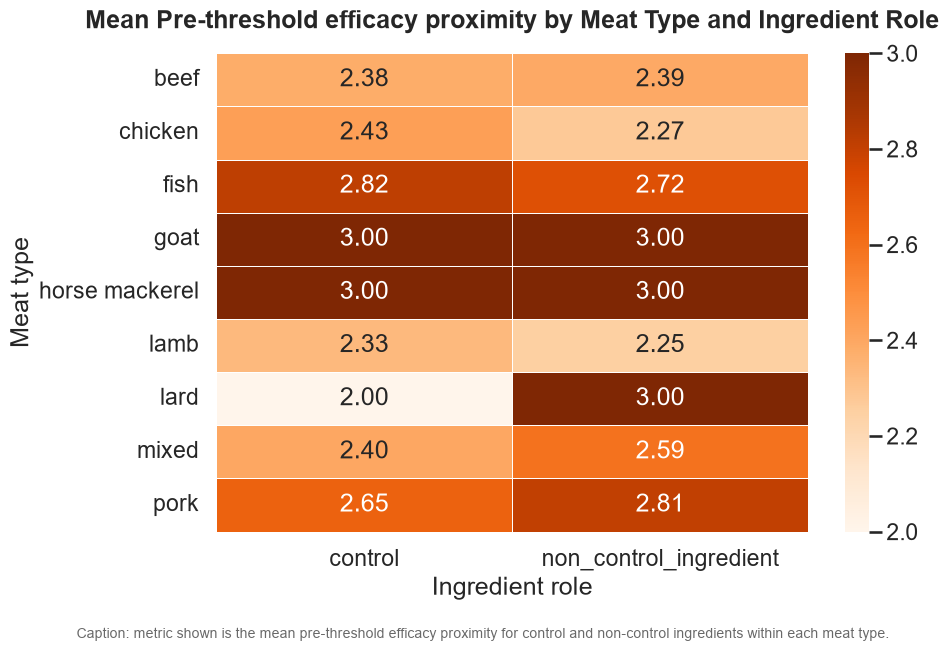

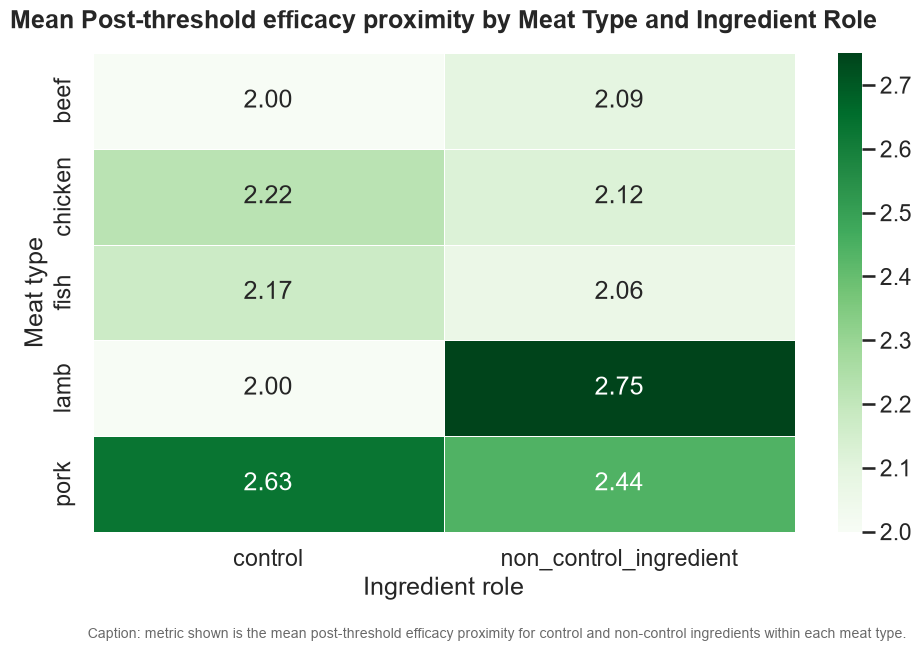

In [50]:
analysis_df['ingredient_role'] = np.where(analysis_df['ingredient'] == 'control', 'control', 'non_control_ingredient')

control_comparison_rows = []
for meat_name, meat_group in analysis_df.groupby('meat_type'):
    for metric in metrics:
        subset = meat_group[['ingredient_role', metric]].dropna()
        role_counts = subset['ingredient_role'].value_counts()
        if role_counts.get('control', 0) < 3 or role_counts.get('non_control_ingredient', 0) < 3:
            continue
        control_values = subset.loc[subset['ingredient_role'] == 'control', metric]
        non_control_values = subset.loc[subset['ingredient_role'] == 'non_control_ingredient', metric]
        control_mean, control_ci_low, control_ci_high = ci_mean(control_values)
        other_mean, other_ci_low, other_ci_high = ci_mean(non_control_values)
        mwu_result = stats.mannwhitneyu(control_values, non_control_values, alternative='two-sided')
        n1 = len(control_values.dropna())
        n2 = len(non_control_values.dropna())
        u_stat = mwu_result.statistic
        rank_biserial = 1 - (2 * u_stat) / (n1 * n2) if n1 and n2 else np.nan
        control_comparison_rows.append({
            'meat_type': meat_name,
            'metric': metric,
            'control_n': n1,
            'non_control_n': n2,
            'control_mean': control_mean,
            'control_ci_low': control_ci_low,
            'control_ci_high': control_ci_high,
            'non_control_mean': other_mean,
            'non_control_ci_low': other_ci_low,
            'non_control_ci_high': other_ci_high,
            'u_statistic': u_stat,
            'p_value': mwu_result.pvalue,
            'rank_biserial_r': rank_biserial,
            'effect_size': abs(rank_biserial),
            'practical_significance': effect_band(rank_biserial, 'correlation'),
            'indicator': 'efficacy proximity',
        })

control_comparison_table = pd.DataFrame(control_comparison_rows).sort_values(['metric', 'meat_type'])
print('Control vs non-control comparison within each meat type: metric = efficacy proximity')
display(control_comparison_table)

# Visual summary: mean efficacy proximity by meat type and ingredient role
for metric, metric_label, cmap in zip(metrics, ['Pre-threshold efficacy proximity', 'Post-threshold efficacy proximity'], ['Oranges', 'Greens']):
    role_pivot = analysis_df.pivot_table(index='meat_type', columns='ingredient_role', values=metric, aggfunc='mean')
    fig, ax = plt.subplots(figsize=(10, 7))
    sns.heatmap(role_pivot, annot=True, fmt='.2f', cmap=cmap, linewidths=0.5, ax=ax)
    ax.set_title(f'Mean {metric_label} by Meat Type and Ingredient Role', pad=18)
    ax.set_xlabel('Ingredient role')
    ax.set_ylabel('Meat type')
    make_caption(fig, f'Caption: metric shown is the mean {metric_label.lower()} for control and non-control ingredients within each meat type.')
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()


## 8. Stratified Analysis by Meat Type

Repeat the efficacy and treatment analysis within each meat type to identify meat-specific concentration effects and treatment differences.

Stratified correlation analysis: metric = concentration-efficacy association within each meat type


,meat_type,metric,test,coefficient,p_value,effect_size,practical_significance,indicator
2,beef,post_threshold_efficacy_proximity,pearson,0.379486,0.026860,0.379486,moderate,normalized concentration vs efficacy proximity
3,beef,post_threshold_efficacy_proximity,spearman,0.216435,0.218901,0.216435,small,normalized concentration vs efficacy proximity
0,beef,pre_threshold_efficacy_proximity,pearson,-0.225504,0.013669,0.225504,small,normalized concentration vs efficacy proximity
1,beef,pre_threshold_efficacy_proximity,spearman,-0.141540,0.124669,0.141540,small,normalized concentration vs efficacy proximity
6,chicken,post_threshold_efficacy_proximity,pearson,-0.132161,0.097861,0.132161,small,normalized concentration vs efficacy proximity
7,chicken,post_threshold_efficacy_proximity,spearman,-0.159182,0.045743,0.159182,small,normalized concentration vs efficacy proximity
4,chicken,pre_threshold_efficacy_proximity,pearson,0.039277,0.516584,0.039277,negligible,normalized concentration vs efficacy proximity
5,chicken,pre_threshold_efficacy_proximity,spearman,-0.039100,0.518474,0.039100,negligible,normalized concentration vs efficacy proximity
10,fish,post_threshold_efficacy_proximity,pearson,-0.107870,0.388625,0.107870,small,normalized concentration vs efficacy proximity
11,fish,post_threshold_efficacy_proximity,spearman,-0.110937,0.375198,0.110937,small,normalized concentration vs efficacy proximity


Within-meat treatment summaries: metric = mean efficacy proximity with 95% CI by treatment


,meat_type,metric,treatment,n,mean,ci_low,ci_high,rank_within_meat
0,beef,pre_threshold_efficacy_proximity,anm,40,2.475000,2.313258,2.636742,1
1,beef,pre_threshold_efficacy_proximity,unspecified,58,2.379310,2.241512,2.517108,2
2,beef,pre_threshold_efficacy_proximity,anm+salt,21,2.333333,2.113453,2.553213,3
3,beef,pre_threshold_efficacy_proximity,anm+map,4,2.000000,2.000000,2.000000,4
4,beef,post_threshold_efficacy_proximity,anm,15,2.133333,1.938477,2.328190,1
5,beef,post_threshold_efficacy_proximity,unspecified,24,2.000000,1.823904,2.176096,2
6,chicken,pre_threshold_efficacy_proximity,anm+irradiation,6,3.000000,3.000000,3.000000,1
7,chicken,pre_threshold_efficacy_proximity,unspecified,69,2.463768,2.336254,2.591282,2
8,chicken,pre_threshold_efficacy_proximity,map+anm,92,2.282609,2.188850,2.376367,3
9,chicken,pre_threshold_efficacy_proximity,anm,107,2.205607,2.111644,2.299571,4


Within-meat Kruskal-Wallis tests: metric = treatment differences inside each meat type


,meat_type,metric,h_statistic,p_value,epsilon_squared,effect_size,practical_significance,indicator,treatment_levels_used,rows_used
3,chicken,post_threshold_efficacy_proximity,40.505145,8.326552e-09,0.243540,0.243540,large,efficacy proximity,4,158
7,lamb,post_threshold_efficacy_proximity,5.250000,2.194677e-02,0.326923,0.326923,large,efficacy proximity,2,15
5,fish,post_threshold_efficacy_proximity,3.740281,5.311551e-02,0.042817,0.042817,small,efficacy proximity,2,66
1,beef,post_threshold_efficacy_proximity,1.025723,3.111654e-01,0.000695,0.000695,negligible,efficacy proximity,2,39
10,pork,post_threshold_efficacy_proximity,0.052220,9.742278e-01,0.000000,0.000000,negligible,efficacy proximity,3,53
2,chicken,pre_threshold_efficacy_proximity,23.180913,3.702409e-05,0.074468,0.074468,moderate,efficacy proximity,4,275
4,fish,pre_threshold_efficacy_proximity,3.097357,7.841952e-02,0.021622,0.021622,small,efficacy proximity,2,99
8,mixed,pre_threshold_efficacy_proximity,2.052503,1.519562e-01,0.042100,0.042100,small,efficacy proximity,2,27
0,beef,pre_threshold_efficacy_proximity,3.878934,2.748374e-01,0.007386,0.007386,negligible,efficacy proximity,4,123
9,pork,pre_threshold_efficacy_proximity,3.066565,3.814756e-01,0.000653,0.000653,negligible,efficacy proximity,4,106


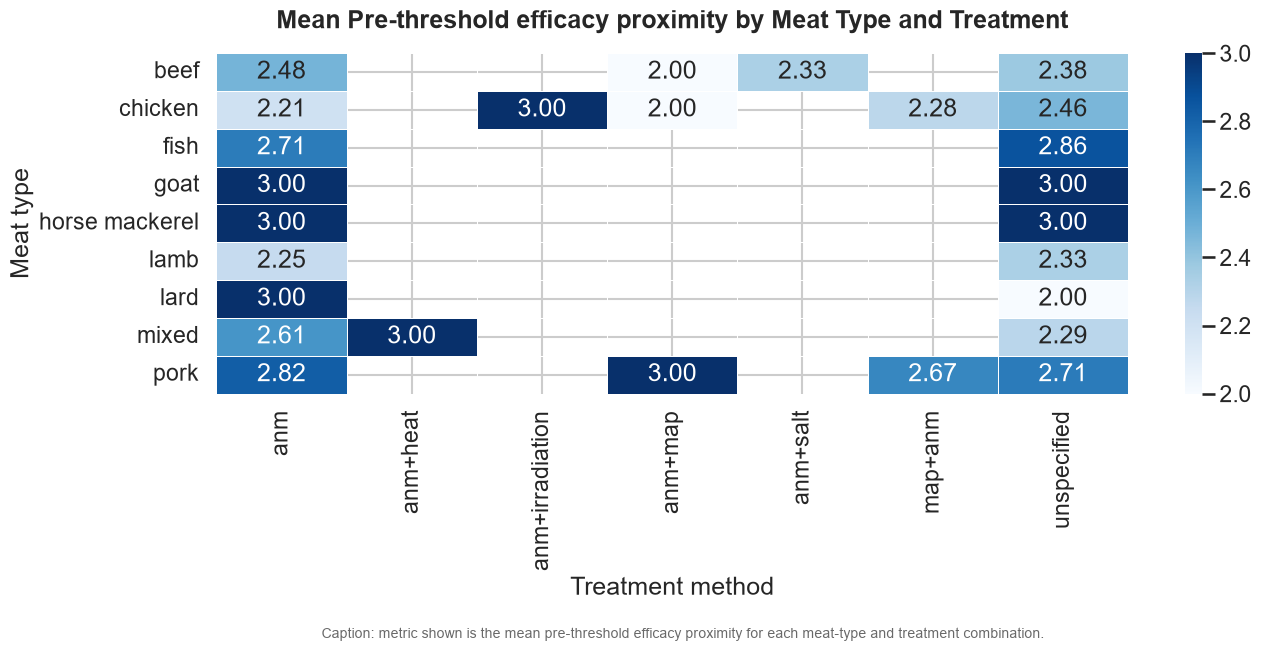

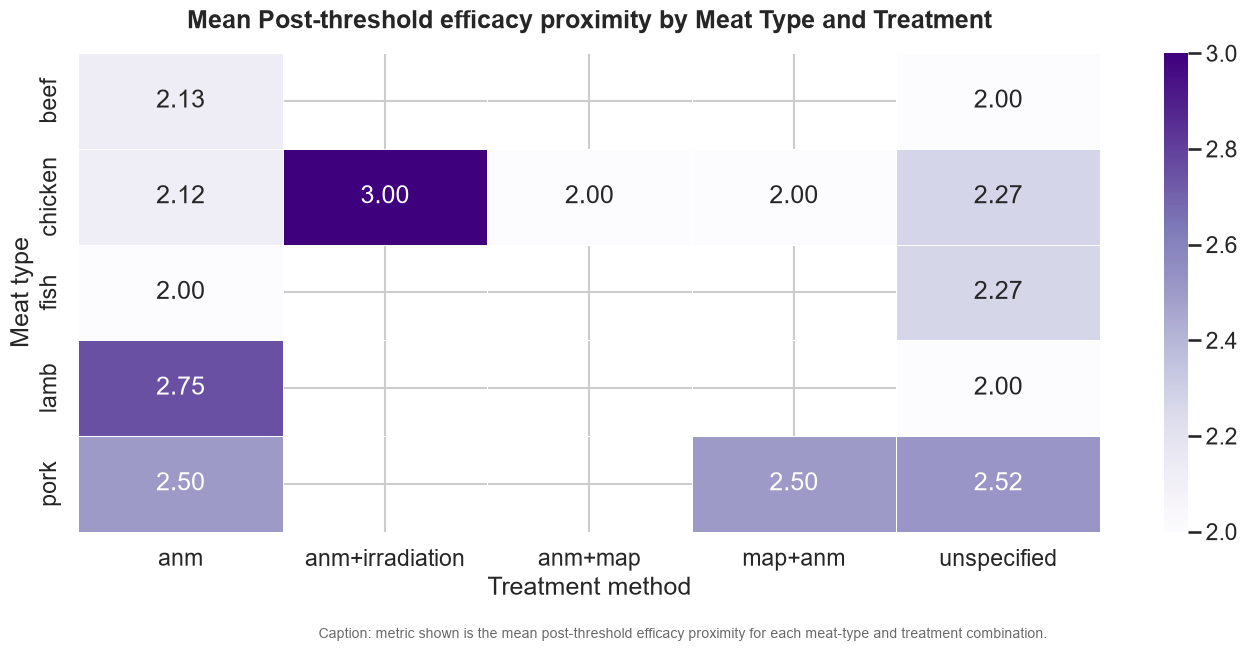

Best and worst treatment by meat type: metric = mean efficacy proximity


,meat_type,metric,best_treatment,best_mean,best_ci_low,best_ci_high,worst_treatment,worst_mean,worst_ci_low,worst_ci_high,indicator
0,beef,pre_threshold_efficacy_proximity,anm,2.475000,2.313258,2.636742,anm+map,2.000000,2.000000,2.000000,efficacy proximity
1,beef,post_threshold_efficacy_proximity,anm,2.133333,1.938477,2.328190,unspecified,2.000000,1.823904,2.176096,efficacy proximity
2,chicken,pre_threshold_efficacy_proximity,anm+irradiation,3.000000,3.000000,3.000000,anm+map,2.000000,2.000000,2.000000,efficacy proximity
3,chicken,post_threshold_efficacy_proximity,anm+irradiation,3.000000,3.000000,3.000000,anm+map,2.000000,2.000000,2.000000,efficacy proximity
4,fish,pre_threshold_efficacy_proximity,unspecified,2.864865,2.749308,2.980422,anm,2.709677,2.593465,2.825890,efficacy proximity
5,fish,post_threshold_efficacy_proximity,unspecified,2.266667,2.008459,2.524874,anm,2.000000,1.838237,2.161763,efficacy proximity
6,goat,pre_threshold_efficacy_proximity,anm,3.000000,3.000000,3.000000,anm,3.000000,3.000000,3.000000,efficacy proximity
7,horse mackerel,pre_threshold_efficacy_proximity,anm,3.000000,3.000000,3.000000,anm,3.000000,3.000000,3.000000,efficacy proximity
8,lamb,pre_threshold_efficacy_proximity,unspecified,2.333333,0.899116,3.767551,anm,2.250000,1.962643,2.537357,efficacy proximity
9,lamb,post_threshold_efficacy_proximity,anm,2.750000,2.462643,3.037357,unspecified,2.000000,2.000000,2.000000,efficacy proximity


In [51]:
# Stratified correlations by meat type
meat_correlation_rows = []
for meat_name, meat_group in analysis_df.groupby('meat_type'):
    for metric in metrics:
        subset = meat_group[['normalized_concentration_pct', metric]].dropna()
        if len(subset) < 5 or subset['normalized_concentration_pct'].nunique() < 2 or subset[metric].nunique() < 2:
            continue
        pearson_result = stats.pearsonr(subset['normalized_concentration_pct'], subset[metric])
        spearman_result = stats.spearmanr(subset['normalized_concentration_pct'], subset[metric])
        meat_correlation_rows.extend([
            {
                'meat_type': meat_name,
                'metric': metric,
                'test': 'pearson',
                'coefficient': pearson_result.statistic,
                'p_value': pearson_result.pvalue,
                'effect_size': abs(pearson_result.statistic),
                'practical_significance': effect_band(pearson_result.statistic, 'correlation'),
                'indicator': 'normalized concentration vs efficacy proximity',
            },
            {
                'meat_type': meat_name,
                'metric': metric,
                'test': 'spearman',
                'coefficient': spearman_result.statistic,
                'p_value': spearman_result.pvalue,
                'effect_size': abs(spearman_result.statistic),
                'practical_significance': effect_band(spearman_result.statistic, 'correlation'),
                'indicator': 'normalized concentration vs efficacy proximity',
            },
        ])

meat_correlation_table = pd.DataFrame(meat_correlation_rows).sort_values(['meat_type', 'metric', 'test'])
print('Stratified correlation analysis: metric = concentration-efficacy association within each meat type')
display(meat_correlation_table)

# Within-meat treatment summaries and tests
within_meat_treatment_rows = []
within_meat_kw_rows = []
for meat_name, meat_group in analysis_df.groupby('meat_type'):
    for metric in metrics:
        summary_rows = []
        metric_data = meat_group[['treatment', metric]].dropna()
        if metric_data.empty:
            continue
        for treatment_name, treatment_group in metric_data.groupby('treatment'):
            mean, ci_low, ci_high = ci_mean(treatment_group[metric])
            summary_rows.append({
                'meat_type': meat_name,
                'metric': metric,
                'treatment': treatment_name,
                'n': int(treatment_group[metric].notna().sum()),
                'mean': mean,
                'ci_low': ci_low,
                'ci_high': ci_high,
            })
        if summary_rows:
            summary_df = pd.DataFrame(summary_rows).sort_values('mean', ascending=False)
            summary_df['rank_within_meat'] = range(1, len(summary_df) + 1)
            within_meat_treatment_rows.append(summary_df)
            grouped_values = [group[metric].dropna().to_numpy() for _, group in metric_data.groupby('treatment') if len(group[metric].dropna()) >= 3]
            if len(grouped_values) >= 2:
                h_stat, p_value = stats.kruskal(*grouped_values)
                epsilon_sq = kruskal_epsilon_squared(h_stat, len(metric_data), len(grouped_values))
                within_meat_kw_rows.append({
                    'meat_type': meat_name,
                    'metric': metric,
                    'h_statistic': h_stat,
                    'p_value': p_value,
                    'epsilon_squared': epsilon_sq,
                    'effect_size': abs(epsilon_sq),
                    'practical_significance': effect_band(epsilon_sq, 'epsilon'),
                    'indicator': 'efficacy proximity',
                    'treatment_levels_used': len(grouped_values),
                    'rows_used': len(metric_data),
                })

if within_meat_treatment_rows:
    within_meat_treatment_table = pd.concat(within_meat_treatment_rows, ignore_index=True)
    print('Within-meat treatment summaries: metric = mean efficacy proximity with 95% CI by treatment')
    display(within_meat_treatment_table)

if within_meat_kw_rows:
    within_meat_kw_table = pd.DataFrame(within_meat_kw_rows).sort_values(['metric', 'p_value'])
    print('Within-meat Kruskal-Wallis tests: metric = treatment differences inside each meat type')
    display(within_meat_kw_table)

# Heatmaps of mean efficacy by meat type and treatment
for metric, metric_label, cmap in zip(metrics, ['Pre-threshold efficacy proximity', 'Post-threshold efficacy proximity'], ['Blues', 'Purples']):
    pivot_table = analysis_df.pivot_table(index='meat_type', columns='treatment', values=metric, aggfunc='mean')
    fig, ax = plt.subplots(figsize=(14, 7))
    sns.heatmap(pivot_table, annot=True, fmt='.2f', cmap=cmap, linewidths=0.5, ax=ax)
    ax.set_title(f'Mean {metric_label} by Meat Type and Treatment', pad=18)
    ax.set_xlabel('Treatment method')
    ax.set_ylabel('Meat type')
    make_caption(fig, f'Caption: metric shown is the mean {metric_label.lower()} for each meat-type and treatment combination.')
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

# Best treatment by meat type for each efficacy metric
best_treatment_rows = []
for meat_name, meat_group in analysis_df.groupby('meat_type'):
    for metric in metrics:
        metric_summary = []
        for treatment_name, treatment_group in meat_group[['treatment', metric]].dropna().groupby('treatment'):
            mean, ci_low, ci_high = ci_mean(treatment_group[metric])
            metric_summary.append((treatment_name, mean, ci_low, ci_high, int(treatment_group[metric].notna().sum())))
        if metric_summary:
            best_treatment = max(metric_summary, key=lambda item: item[1])
            worst_treatment = min(metric_summary, key=lambda item: item[1])
            best_treatment_rows.append({
                'meat_type': meat_name,
                'metric': metric,
                'best_treatment': best_treatment[0],
                'best_mean': best_treatment[1],
                'best_ci_low': best_treatment[2],
                'best_ci_high': best_treatment[3],
                'worst_treatment': worst_treatment[0],
                'worst_mean': worst_treatment[1],
                'worst_ci_low': worst_treatment[2],
                'worst_ci_high': worst_treatment[3],
                'indicator': 'efficacy proximity',
            })

best_treatment_table = pd.DataFrame(best_treatment_rows)
print('Best and worst treatment by meat type: metric = mean efficacy proximity')
display(best_treatment_table)
